## 🔄 Simple TOPFARM Example

This notebook walks through a minimal wind-farm design optimization that couples **OptiWindNet**(electrical-network routing) with **[TopFarm](https://gitlab.windenergy.dtu.dk/TOPFARM)**(turbine-layout optimization), and uses the standalone **`costmodels`**package for offshore CAPEX/OPEX and project finance.

* **Three cost components**:

 * **Energy (AEP)**: PyWake evaluates farm energy for a set of wind directions and turbine coordinates.
 * **Electrical network (cabling)**: based on turbine/substation coordinates and the cable catalogue, `WFNComponent` (a TopFarm wrapper around OptiWindNet's `WindFarmNetwork`) returns cabling cost (and gradients).
 * **Economics (NPV)**: a `costmodels.project.Project` with a `Technology` backed by `DTUOffshoreCostModel` returns project NPV given AEP and cabling cost. NPV is the optimization **objective**(`maximize=True`); IRR, LCOE, CAPEX and OPEX are tracked as auxiliary outputs.

* **Design variables**— the optimizer is free to move:

 * `x`, `y`: turbine coordinates (one entry per turbine)
 * `xs`, `ys`: **substation coordinates**— letting TopFarm co-locate the substation alongside the turbines reduces total cabling cost. The boundary constraint applies to turbines only; the substation is unconstrained, so its trajectory may exit the site polygon. The final substation position is shown in a dedicated trajectory plot at the end.

**How it plugs into TopFarm**

1. We instantiate each component: `aep_comp`, `network_cost_comp`, and `npv_comp`.
2. We combine them in a `TopFarmGroup([aep_comp, network_cost_comp, npv_comp])`. With promotion, outputs/inputs line up automatically:

 * `aep_comp` produces **AEP**used by the economic component.
 * `network_cost_comp` produces **cabling_cost**also used by the economic component.
 * The economic component outputs **NPV**, which TopFarm treats as the **objective**.
3. We create a `TopFarmProblem` with the turbine **and substation**coordinates as design variables, the `TopFarmGroup` cost component, the layout constraints, and a driver.
4. We call `optimize()` to run the optimization.

Dataflow: `(turbine & substation positions) AEP & cabling_cost NPV (objective)`. Constraints keep the turbine layout feasible; the chosen OptiWindNet router controls the network quality/speed trade-off.

> **Note on boundaries and buffering**
>
> TopFarm’s gradient-based drivers occasionally move turbines a little outside the user-defined site polygon while searching the design space.
> OptiWindNet can accommodate these small excursions with
> `wfn.add_buffer(buffer_dist=dist)`, which expands the outer border and shrinks any obstacle polygons by `dist` before it optimizes the electrical network.
>
> In this demo notebook we omit the border when we instantiate `WindFarmNetwork` because the rectangular site has no concavities or internal obstacles, and we don’t know in advance how far the topfarm driver might overshoot. In real projects (especially when the site has concavity or exclusion zones), the user should
>
> 1. **Estimate the maximum overshoot**the chosen TopFarm driver may produce (e.g. by running a few test iterations or inspecting previous layouts).
> 2. Call `wfn.add_buffer(buffer_dist=max_overshoot)` *before* optimisation, or pass the buffered border/obstacles directly when creating the `WindFarmNetwork`.
>
> This ensures OptiWindNet always receives a feasible geometry, while keeping the electrical-network solution as much as possible consistent with the true site limits.

Import required packages

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from py_wake.examples.data.dtu10mw import DTU10MW
from py_wake.examples.hornsrev1_example import Hornsrev1Site
from py_wake import Nygaard_2022

from topfarm import TopFarmProblem, TopFarmGroup
from topfarm.cost_models.py_wake_wrapper import PyWakeAEPCostModelComponent
from topfarm.cost_models.cost_model_wrappers import CostModelComponent
from topfarm.cost_models.electrical.optiwindnet_wrapper import WFNComponent
from topfarm.constraint_components.boundary import XYBoundaryConstraint
from topfarm.constraint_components.constraint_aggregation import DistanceConstraintAggregation
from topfarm.easy_drivers import EasySGDDriver
from topfarm.plotting import XYPlotComp

from optiwindnet.api import MILPRouter
from optiwindnet.augmentation import poisson_disc_filler

from costmodels.finance import Depreciation, Technology, Product
from costmodels.project import Project
from costmodels.models import DTUOffshoreCostModel

In [3]:
%config InlineBackend.figure_formats = ['svg']
plt.rcParams['svg.fonttype'] = 'none'

# matplotlib >=3.9 removed rcsetup.interactive_bk (moved to backend_registry);
# restore it so topfarm.plotting works with newer matplotlib
import matplotlib
if not hasattr(matplotlib.rcsetup, 'interactive_bk'):
    from matplotlib.backends.registry import backend_registry, BackendFilter
    matplotlib.rcsetup.interactive_bk = backend_registry.list_builtin(BackendFilter.INTERACTIVE)
    matplotlib.rcsetup.non_interactive_bk = backend_registry.list_builtin(BackendFilter.NON_INTERACTIVE)
    matplotlib.rcsetup.all_backends = backend_registry.list_builtin()

### Wind farm design parameters

Define turbine type and count:

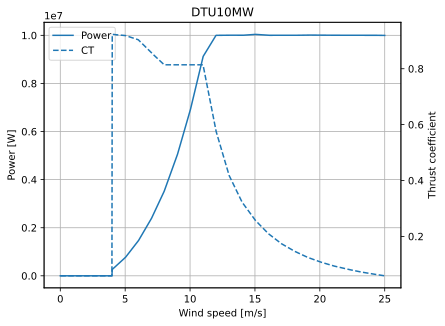

In [4]:
wind_turbines = DTU10MW()
n_wt = 20
wind_turbines.plot_power_ct();

Define the wind resource:

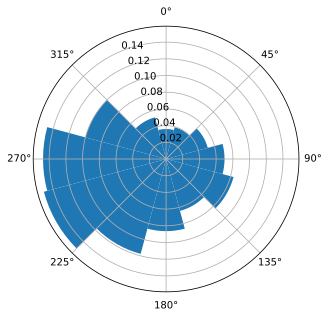

In [5]:
site = Hornsrev1Site()
site.plot_wd_distribution();

Define the area:

In [6]:
d_west_east = 4000  # [m] width
d_south_north = 2000  # [m] height
min_wt_spacing = 3.5 * wind_turbines.diameter()  # [m] inter-turbine minimum distance
boundary = np.array([
    (0, 0),
    (d_west_east, 0),
    (d_west_east, d_south_north),
    (0, d_south_north),
])

Define the substation position (will also be a design variable in the optimization):

In [7]:
x_ss_init, y_ss_init = (d_west_east / 5, d_south_north / 2)

### Initial wind farm layout (turbine positions)

In [8]:
# Generate initial random turbine layout
x_init, y_init = poisson_disc_filler(
    n_wt,
    min_dist=min_wt_spacing,
    BorderC=boundary,
    seed=42,
    
).T

### Build components

#### AEP component

In [9]:
# number of wind directions to consider
n_wd = 12

wfm = Nygaard_2022(site=site, windTurbines=wind_turbines)

aep_comp = PyWakeAEPCostModelComponent(
    windFarmModel=wfm,
    n_wt=n_wt,
    wd=np.linspace(0.0, 360.0, n_wd, endpoint=False),
    objective=False,
)

#### Electrical network component

##### Choose the router

Pick one of the available routers in OptiWindNet:

**EWRouter**

```python
from optiwindnet.api import EWRouter
router = EWRouter()
```

**HGSRouter**

```python
from optiwindnet.api import HGSRouter
router = HGSRouter(time_limit=0.1) # seconds
```

**MILPRouter**

```python
from optiwindnet.api import MILPRouter
router = MILPRouter(
 solver_name='gurobi', # or 'highs', 'cplex'
 time_limit=1, # seconds
 mip_gap=0.005, # relative optimality gap (0.5%)
 verbose=True
)
```

> The selected `router` is passed to `WFNComponent`, which forwards it to OptiWindNet's `WindFarmNetwork`. If you use `MILPRouter`, make sure a supported solver is installed (and licensed if necessary).

Let's proceed with `MILPRouter` for this example. You can easily switch to other routers using the sample code above.

In [10]:
router = MILPRouter(solver_name='ortools.cp_sat', time_limit=0.1, mip_gap=0.005)

Assemble initial turbine/substation positions in OptiWindNet format.

In [11]:
turbines_pos = np.column_stack((x_init, y_init))
substations_pos = np.column_stack(([x_ss_init], [y_ss_init]))

Define cables. Each row is `[<max number of turbines this cable can carry>, <cable price in €/m>]`.

In [12]:
cables = np.array([(2, 2000), (5, 2200)])

Build the cabling cost component using TopFarm's `WFNComponent` (a thin wrapper around OptiWindNet's `WindFarmNetwork` exposing cost and gradient hooks). The component takes turbine and substation coordinates as inputs and outputs `cabling_cost` (plus the network length and topology-aware `terse_links`).

In [13]:
network_cost_comp = WFNComponent(
    turbines_pos=turbines_pos,
    substations_pos=substations_pos,
    cables=cables,
    router=router,
)

#### Economic component (NPV objective)

We use the `costmodels` package to assemble a single-technology offshore wind project. `DTUOffshoreCostModel` provides the technology-level CAPEX/OPEX cost model; `Technology` wraps it with finance parameters (lifetime, WACC, OPEX, product); `Project` aggregates technologies into a project that can compute NPV (and IRR, LCOE, CAPEX, OPEX as auxiliaries).

We expose an `economic_func` (and its analytical gradient `economic_func_grad`) that takes `AEP` (in GWh) and `cabling_cost` (in €) and returns the project NPV. The cabling cost is fed in as `shared_capex` so it adds to the project CAPEX. Water depth is held fixed across the site for this simple example.

In [14]:
LIFETIME = 25         # [years]
EL_PRICE = 60         # [€/MWh] flat PPA price (matches the original notebook's 0.06 €/kWh)
WATER_DEPTH = 33.0    # [m] uniform site water depth
DISTANCE_FROM_SHORE = 30  # [km] (informational — not used by DTUOffshoreCostModel directly)

RP_MW = float(wind_turbines.power(20.0)) * 1e-6  # rated power [MW]

# Reference AEP (used only to seed the model with a plausible capacity factor)
_simres_ref = wfm(x_init, y_init)
_aep_ref_gwh = float(_simres_ref.aep().values.sum())
CF_ref = _aep_ref_gwh * 1e3 / (RP_MW * 24 * 365 * n_wt)

cost_model = DTUOffshoreCostModel(
    rated_power=RP_MW,
    rotor_speed=12.0,
    rotor_diameter=wind_turbines.diameter(),
    hub_height=wind_turbines.hub_height(),
    lifetime=LIFETIME,
    capacity_factor=CF_ref,
    nwt=n_wt,
    profit=0,
)

wind_plant = Technology(
    name='wind',
    lifetime=LIFETIME,
    product=Product.SPOT_ELECTRICITY,
    opex=12600 * n_wt * RP_MW + 1.35 * _aep_ref_gwh * 1000,  # [€/yr]
    wacc=0.06,
    cost_model=cost_model,
)

project = Project(
    technologies=[wind_plant],
    product_prices={Product.SPOT_ELECTRICITY: EL_PRICE},
    depreciation=Depreciation(rate=(0, 1), year=(0, LIFETIME)),
)

water_depth_array = np.full((n_wt,), WATER_DEPTH)

In [15]:
def economic_func(AEP, cabling_cost, **kwargs):
    aep_mwh = AEP * 1e3  # GWh → MWh
    npv, aux = project.npv(
        productions={wind_plant.name: aep_mwh},
        cost_model_args={
            wind_plant.name: {'water_depth': water_depth_array, 'aep': aep_mwh},
        },
        finance_args={'shared_capex': cabling_cost},
        return_aux=True,
    )
    return npv, {
        'IRR': aux['IRR'],
        'LCOE': aux['LCOE'][0],
        'CAPEX': aux['CAPEX'],
        'OPEX': float(np.mean(aux['OPEX'])),
    }


def economic_func_grad(AEP, cabling_cost, **kwargs):
    aep_mwh = AEP * 1e3
    grad = project.npv_grad(
        productions={wind_plant.name: aep_mwh},
        cost_model_args={
            wind_plant.name: {'water_depth': water_depth_array, 'aep': aep_mwh},
        },
        finance_args={'shared_capex': cabling_cost},
    )
    return (
        grad[0][wind_plant.name] * 1e3,    # dNPV/dAEP (chain rule for GWh→MWh)
        grad[2]['shared_capex'],           # dNPV/dCablingCost
    )

In [16]:
npv_comp = CostModelComponent(
    input_keys=[('AEP', 0.0), ('cabling_cost', 0.0)],
    n_wt=n_wt,
    cost_function=economic_func,
    cost_gradient_function=economic_func_grad,
    output_keys=[('NPV', 0.0)],
    additional_output=[
        ('IRR', 0.0),
        ('LCOE', 0.0),
        ('CAPEX', 0.0),
        ('OPEX', 0.0),
    ],
    objective=True,
    maximize=True,
)

### Build TopFarm problem

Combine the three cost components in a `TopFarmGroup`.

In [17]:
cost_comp = TopFarmGroup([
    aep_comp,
    network_cost_comp,
    npv_comp,
])

Create the `TopFarmProblem`. Design variables are the turbine coordinates `x`, `y` **and**the substation coordinates `xs`, `ys` — letting the optimizer co-locate the substation reduces total cabling cost.

In [18]:
tf_problem = TopFarmProblem(
    design_vars=dict(
        x=x_init,
        y=y_init,
        xs=x_ss_init,
        ys=y_ss_init,
    ),
    cost_comp=cost_comp,
    constraints=DistanceConstraintAggregation(
        XYBoundaryConstraint(boundary, 'polygon'),
        n_wt,
        min_wt_spacing,
        wind_turbines,
    ),
    driver=EasySGDDriver(maxiter=500),
    plot_comp=XYPlotComp(),
)

### Run optimization

We use `maxiter=10` here so the example runs quickly end-to-end. Increase it for a meaningful optimization.

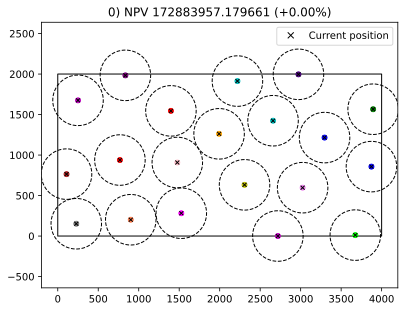

Optimized in	160.108s


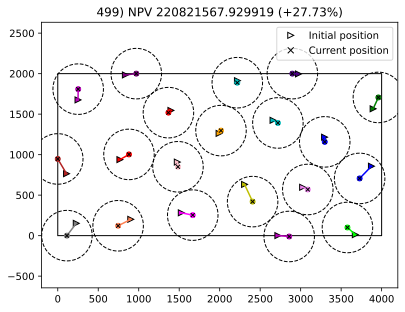

In [19]:
cost, state, recorder = tf_problem.optimize(disp=True)

### Plotting
Track AEP, cabling cost, NPV, IRR and constraint violation over time.

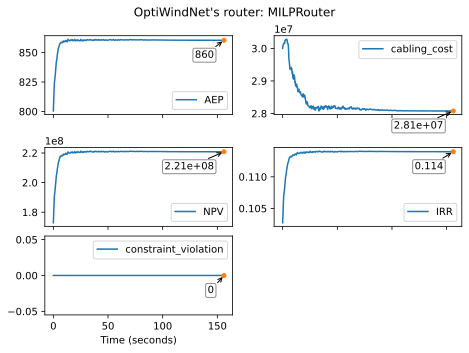

In [20]:
records_to_plot = ['AEP', 'cabling_cost', 'NPV', 'IRR', 'constraint_violation']
time = recorder['timestamp'] - recorder['timestamp'][0]
n_rows = math.ceil(len(records_to_plot) / 2)
fig, axs = plt.subplots(n_rows, 2, sharex=True, layout='constrained')

for ax, key in zip(axs.ravel(), records_to_plot):
    line, = ax.plot(time, recorder[key], label=key)
    ax.legend()
    x_last, y_last = line.get_xdata()[-1], line.get_ydata()[-1]
    ax.plot(x_last, y_last, 'o', ms=4)
    ax.annotate(
        f'{y_last:.3g}',
        xy=(x_last, y_last),
        xytext=(-10, -10), textcoords='offset points',
        ha='right', va='top',
        arrowprops=dict(arrowstyle='->', lw=1),
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='0.5', alpha=0.9),
    )

# hide any unused axes (when records_to_plot is odd)
for ax in axs.ravel()[len(records_to_plot):]:
    ax.set_visible(False)

for ax in axs[-1, :]:
    ax.set_xlabel('Time (seconds)')

fig.suptitle(f"OptiWindNet's router: {type(router).__name__}");

#### Substation trajectory

Because `xs`, `ys` are design variables (and unconstrained by the site polygon), the substation drifts during optimization. The plot below overlays the site boundary, the **initial**substation position (open marker), the **final**position (filled marker), and the **path**the optimizer took, plus the final turbine layout for context.

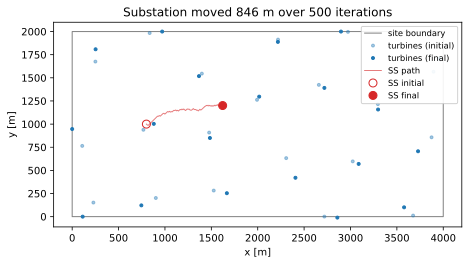

In [21]:
xs_path = np.asarray(recorder['xs']).reshape(-1)
ys_path = np.asarray(recorder['ys']).reshape(-1)
x_final = np.asarray(recorder['x'])[-1].reshape(-1)
y_final = np.asarray(recorder['y'])[-1].reshape(-1)

fig, ax = plt.subplots(layout='constrained')
ax.set_aspect('equal')

# site boundary
ax.plot(
    np.r_[boundary[:, 0], boundary[0, 0]],
    np.r_[boundary[:, 1], boundary[0, 1]],
    color='0.5', lw=1, label='site boundary',
)

# turbines (initial vs final)
ax.plot(x_init, y_init, '.', color='C0', alpha=0.4, label='turbines (initial)')
ax.plot(x_final, y_final, '.', color='C0', label='turbines (final)')

# substation trajectory
ax.plot(xs_path, ys_path, '-', color='C3', lw=1, alpha=0.6, label='SS path')
ax.plot(xs_path[0], ys_path[0], 'o', mfc='none', mec='C3', ms=8, label='SS initial')
ax.plot(xs_path[-1], ys_path[-1], 'o', mfc='C3', mec='C3', ms=8, label='SS final')

ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.legend(loc='upper right', fontsize='small', framealpha=0.9)
ax.set_title(
    f'Substation moved {np.hypot(xs_path[-1] - xs_path[0], ys_path[-1] - ys_path[0]):.0f} m '
    f'over {len(xs_path)} iterations'
);

Plot the optimized network for the final wind farm layout.

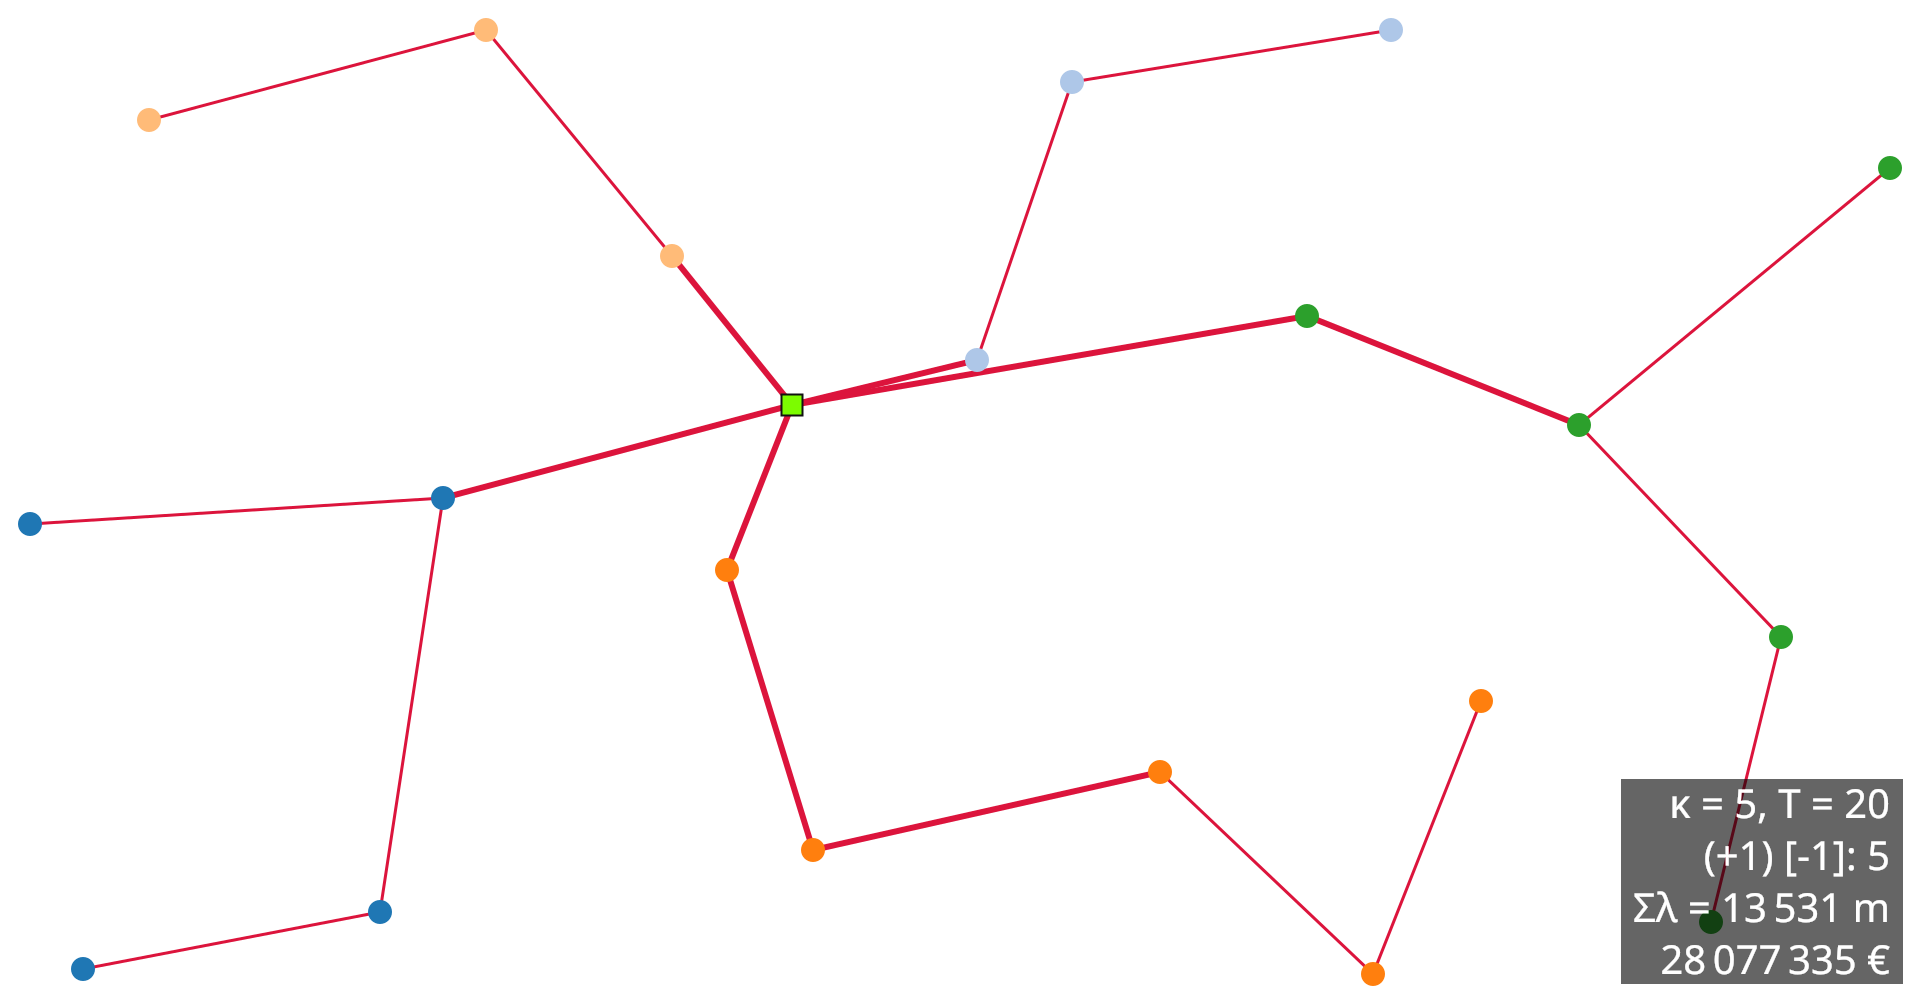

In [22]:
network_cost_comp.wfn.plot()